[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/gse-unil/2026_Geoinformatique_II/blob/main/tps/tp-py03.ipynb) [![Open in Kaggle](https://img.shields.io/badge/Open%20in-Kaggle-20BEFF?logo=kaggle&logoColor=white)](https://www.kaggle.com/kernels/welcome?src=https://github.com/gse-unil/2026_Geoinformatique_II/blob/main/tps/tp-py03.ipynb) [![Launch on Renku](https://renkulab.io/renku-badge.svg)]({{ MOODLE_RENKU_URL }})

> **Exécution dans le cloud** : ce notebook peut aussi tourner dans le cloud (Colab, Kaggle, Renku).
> Avant de lancer les cellules, télécharge `tp3.gpkg` depuis le dossier OneDrive du cours et dépose-le dans le répertoire de travail du notebook (Colab : panneau 📁 → *Upload* ; Kaggle : *File → Upload* ; Renku : déjà dans le projet).
> Procédure complète : [docs/cloud-badges.md](https://github.com/gse-unil/2026_Geoinformatique_II/blob/main/docs/cloud-badges.md).


# TP Python 3 : Géotraitement vectoriel & modèles non-linéaires

Ce TP Python est le pendant numérique du **TP QGIS 3**. Tu vas reproduire les mêmes opérations de géotraitement vectoriel en Python, puis appliquer des modèles de régression non-linéaires sur des données géographiques historiques.

| Partie | Bibliothèque | Ce que tu apprendras |
|--------|-------------|----------------------|
| **1. Sélection & extraction** | `geopandas` | Sélectionner des entités par attribut, dissoudre, découper |
| **2. Zones tampons** | `geopandas` / `shapely` | Créer des buffers, définir la zone urbaine (ZDB, ZU) |
| **3. Superposition** | `geopandas` / `shapely` | Union, différence, intersection → WUI |
| **4. GAM** | `statsmodels` / `sklearn` | Modèles additifs généralisés, splines, lisseur spatial, validation croisée |

> 🔗 **Lien avec le TP QGIS 3** : les parties 1–3 reproduisent en Python le même résultat que dans QGIS —
> la **zone d'interface habitat-forêt (WUI)** du district bernois de _Frutigen-Niedersimmental_.
> La partie 4 applique des GAM au dataset **Guerry** (France, années 1830) pour modéliser
> l'alphabétisation en fonction de variables socio-économiques et d'un lisseur spatial.

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.patches import Patch

import rasterio
from rasterio.transform import from_bounds
from rasterio.crs import CRS
from rasterio.features import rasterize

from scipy.ndimage import distance_transform_edt

import geopandas as gpd

from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (classification_report, confusion_matrix,
                             ConfusionMatrixDisplay, mean_absolute_error, r2_score)


In [2]:
# -------------------------------------------------------
# Chargement des données vectorielles depuis tp3.gpkg
# -------------------------------------------------------
GPKG_PATH = "tp3.gpkg"
CRS_REF   = 'EPSG:21781'   # CH1903 / LV03

foret     = gpd.read_file(GPKG_PATH, layer='Foret').to_crs(CRS_REF)
buildings = gpd.read_file(GPKG_PATH, layer='Buildings').to_crs(CRS_REF)
roads     = gpd.read_file(GPKG_PATH, layer='Roads').to_crs(CRS_REF)
communes  = gpd.read_file(GPKG_PATH, layer='Communes').to_crs(CRS_REF)
districts = gpd.read_file(GPKG_PATH, layer='Districts').to_crs(CRS_REF)

print("Couches vectorielles chargées depuis tp3.gpkg :")
for name, gdf in [
    ('Foret',     foret),
    ('Buildings', buildings),
    ('Roads',     roads),
    ('Communes',  communes),
    ('Districts', districts),
]:
    geom_type = gdf.geometry.geom_type.iloc[0]
    print(f"  {name:12s}: {len(gdf):7d} entités | CRS: EPSG:{gdf.crs.to_epsg()} | géométrie: {geom_type}")


ERROR 1: PROJ: proj_create_from_database: Open of /home/jsoutter/anaconda3/envs/landslide/share/proj failed


Couches vectorielles chargées depuis tp3.gpkg :
  Foret       :   13461 entités | CRS: EPSG:21781 | géométrie: MultiPolygon
  Buildings   :  373399 entités | CRS: EPSG:21781 | géométrie: MultiPolygon
  Roads       :  112567 entités | CRS: EPSG:21781 | géométrie: MultiLineString
  Communes    :    8868 entités | CRS: EPSG:21781 | géométrie: MultiPolygon
  Districts   :     233 entités | CRS: EPSG:21781 | géométrie: MultiPolygon


---
## Partie 1 — Sélection et extraction

Dans le TP QGIS 3, nous avons commencé par sélectionner les districts bernois de
_Frutigen-Niedersimmental_ et _Obersimmental-Saanen_, les avons fusionnés pour
définir le périmètre d'étude, puis avons découpé les autres couches dans ce périmètre.

En Python avec **geopandas**, les équivalents sont :

| Outil QGIS | Équivalent Python |
|---|---|
| Sélection par expression | `gdf[gdf['col'].str.contains(...)]` |
| Fusionner les entités | `gdf.dissolve()` |
| Couper (*Clip*) | `gpd.clip(layer, mask)` |

### 1.1 Sélection des districts et fusion (étapes 2a/2b)


On sélectionne les districts par expression (équivalent du filtre SQL `"NAME" ILIKE '...'`
dans QGIS), puis on les **fusionne en une seule entité** (`dissolve`) pour
définir le périmètre global de la zone d'étude.


Districts sélectionnés (1) :
  • Frutigen-Niedersimmental

Zone d'étude fusionnée : 1 polygone
  Aire totale  : 1349.1 km²
  Périmètre    : 205.5 km


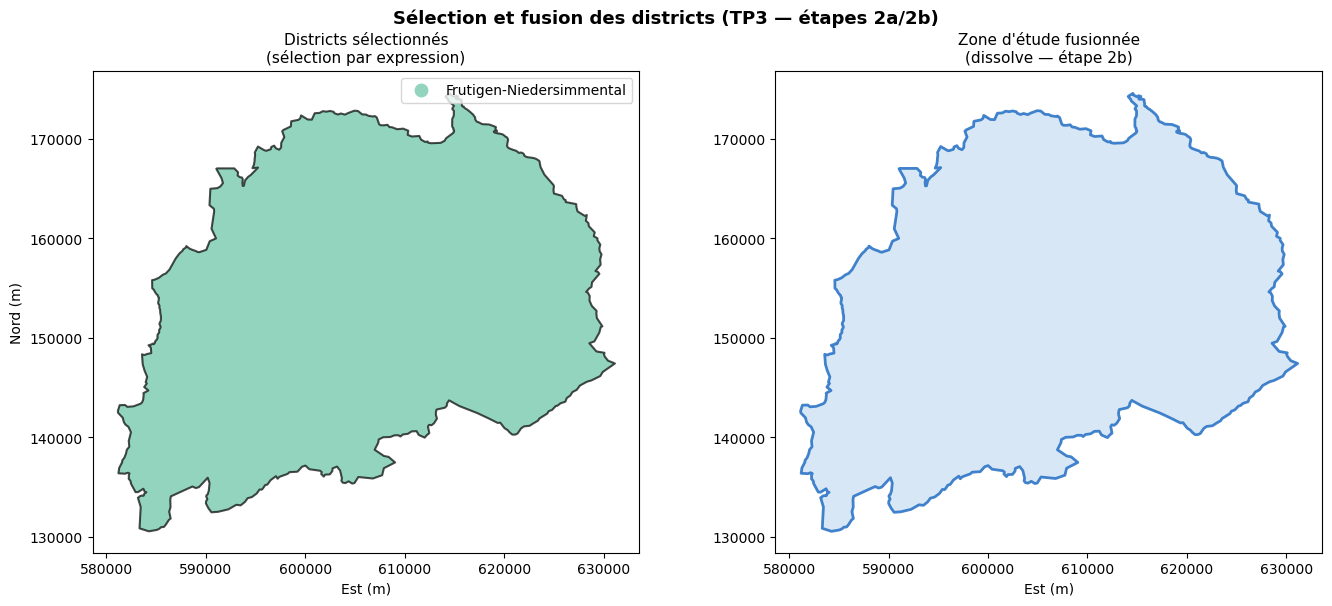

In [3]:
# -------------------------------------------------------
# 2a — Sélection par expression (= filtre SQL dans QGIS)
# -------------------------------------------------------
study_districts = districts[
    districts['NAME'].str.contains(
        'Frutigen-Niedersimmental|Obersimmental-Saanen',
        case=False, na=False
    )
].copy()

print(f"Districts sélectionnés ({len(study_districts)}) :")
for _, row in study_districts.iterrows():
    print(f"  • {row['NAME']}")

# -------------------------------------------------------
# 2b — Fusionner les entités (= dissolve / Fusionner dans QGIS)
# -------------------------------------------------------
study_area = study_districts.dissolve().reset_index(drop=True)[['geometry']]

print(f"\nZone d'étude fusionnée : 1 polygone")
print(f"  Aire totale  : {study_area.geometry.area.iloc[0] / 1e6:.1f} km²")
print(f"  Périmètre    : {study_area.geometry.length.iloc[0] / 1e3:.1f} km")

# -------------------------------------------------------
# Visualisation
# -------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

study_districts.plot(ax=axes[0], column='NAME', cmap='Set2',
                     edgecolor='black', linewidth=1.5, alpha=0.7, legend=True)
axes[0].set_title('Districts sélectionnés\n(sélection par expression)', fontsize=11)
axes[0].set_xlabel('Est (m)')
axes[0].set_ylabel('Nord (m)')

study_area.plot(ax=axes[1], facecolor='#cfe2f3', edgecolor='#1565c0',
                linewidth=2, alpha=0.8)
axes[1].set_title('Zone d\'étude fusionnée\n(dissolve — étape 2b)', fontsize=11)
axes[1].set_xlabel('Est (m)')

plt.suptitle('Sélection et fusion des districts (TP3 — étapes 2a/2b)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


### 1.2 Découpage des couches (étape 2c)

Une fois le périmètre défini, on découpe toutes les couches avec **`gpd.clip()`**,
l'équivalent de l'outil **Couper** (*Clip*) dans QGIS.
Cela garantit que les géotraitements suivants ne portent que sur la zone d'étude.


Découpage des couches à la zone d'étude...



Résultat du découpage :
  Forêt       :    409 entités
  Bâtiments   :   2680 entités
  Routes      :    806 entités
  Communes    :     48 entités


/tmp/ipykernel_441346/2914653568.py:38: UserWarning: Legend does not support handles for PatchCollection instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  ax.legend(loc='upper right', fontsize=9)


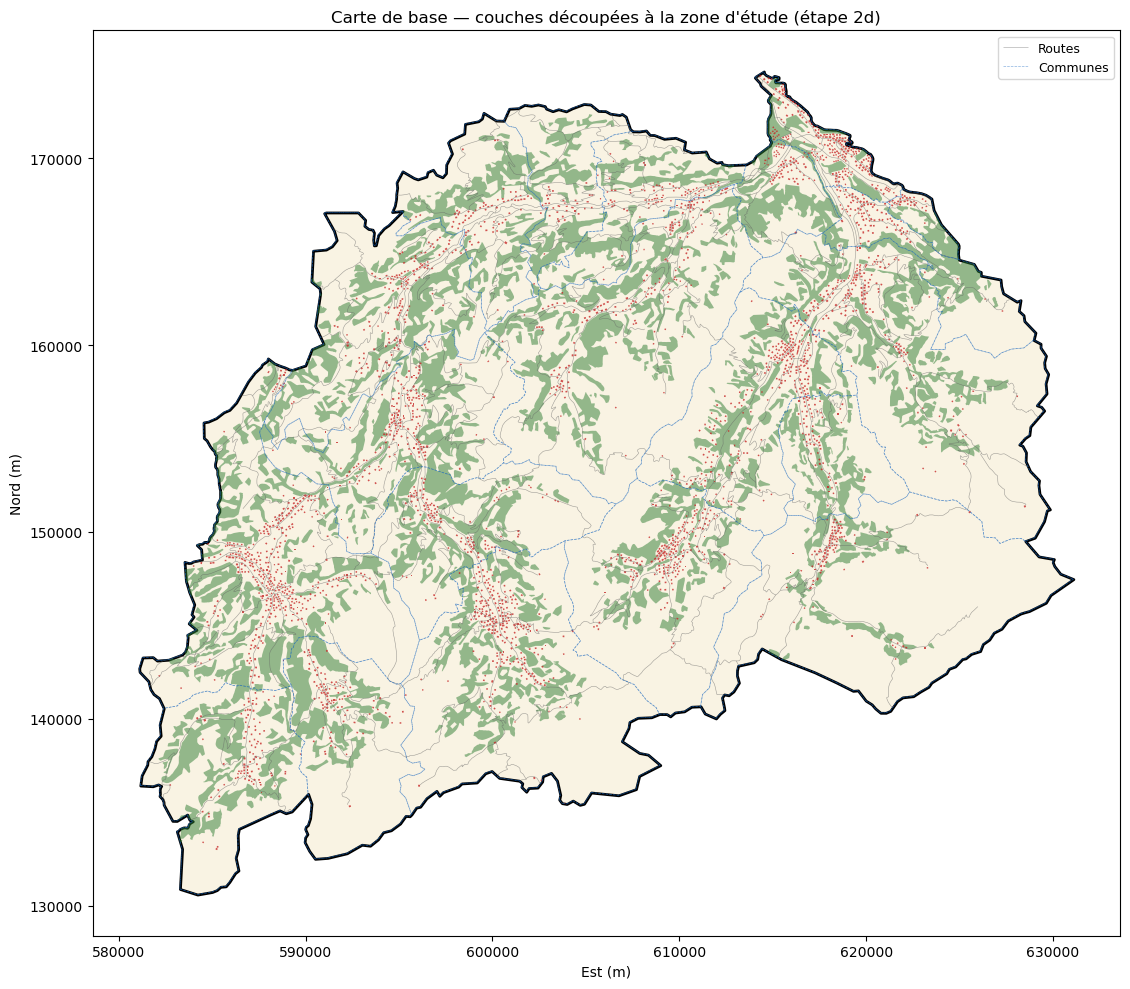

In [4]:
# -------------------------------------------------------
# 2c — Découpage (= outil Clip dans QGIS)
# -------------------------------------------------------
print("Découpage des couches à la zone d'étude...")

foret_clip     = gpd.clip(foret,     study_area).reset_index(drop=True)
buildings_clip = gpd.clip(buildings, study_area).reset_index(drop=True)
roads_clip     = gpd.clip(roads,     study_area).reset_index(drop=True)
communes_clip  = gpd.clip(communes,  study_area).reset_index(drop=True)

print("\nRésultat du découpage :")
for name, gdf in [
    ('Forêt',      foret_clip),
    ('Bâtiments',  buildings_clip),
    ('Routes',     roads_clip),
    ('Communes',   communes_clip),
]:
    print(f"  {name:12s}: {len(gdf):6d} entités")

# -------------------------------------------------------
# Carte de base découpée (étape 2d dans QGIS)
# -------------------------------------------------------
fig, ax = plt.subplots(figsize=(12, 10))

study_area.plot(ax=ax, facecolor='#f9f3e3', edgecolor='black', linewidth=2, zorder=1)
foret_clip.plot(ax=ax, color='#2e7d32', alpha=0.5, label='Forêt', zorder=2)
buildings_clip.plot(ax=ax, color='#c62828', alpha=0.8, markersize=0.3,
                    label='Bâtiments', zorder=3)
roads_clip.plot(ax=ax, color='#616161', linewidth=0.4, alpha=0.6,
                label='Routes', zorder=4)
communes_clip.plot(ax=ax, facecolor='none', edgecolor='#1565c0',
                   linewidth=0.5, linestyle='--', alpha=0.5,
                   label='Communes', zorder=5)

ax.set_title('Carte de base — couches découpées à la zone d\'étude (étape 2d)', fontsize=12)
ax.set_xlabel('Est (m)')
ax.set_ylabel('Nord (m)')
ax.legend(loc='upper right', fontsize=9)
plt.tight_layout()
plt.show()


---
## Partie 2 — Zones tampons (Buffer)

Les zones tampons permettent de définir des zones de proximité autour d'entités.
Dans QGIS, nous avons utilisé l'outil **Zone tampon** pour :

1. **Zone Densément Bâtie (ZDB)** — buffer `+75 m` sur les bâtiments (regroupé),
   puis buffer `−75 m` pour conserver uniquement les zones densément bâties
2. **Emprise des routes** — buffer de `6 m` (= moitié de la largeur de 12 m)

| Outil QGIS | Équivalent Python |
|---|---|
| Zone tampon (Buffer) | `.buffer(distance)` sur `geometry` |
| Regrouper le résultat | `.unary_union` (fusionne en une seule géométrie) |

### 2.1 ZDB — Zone Densément Bâtie (étape 3a)


Étape 1 : buffer +75 m sur les bâtiments (regroupé)...


/tmp/ipykernel_441346/3863927220.py:7: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  buf_pos = buildings_clip.geometry.buffer(75).unary_union   # buffer + dissolve


Étape 2 : buffer −75 m pour garder uniquement les zones denses (ZDB)...


  ZDB : aire totale = 32.30 km²

Buffer routes (6 m)...


/tmp/ipykernel_441346/3863927220.py:18: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  roads_buf_geom = roads_clip.geometry.buffer(6).unary_union


  Routes bufferisées : aire = 15.05 km²


/tmp/ipykernel_441346/3863927220.py:33: UserWarning: Legend does not support handles for PatchCollection instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  axes[0].legend(fontsize=8)
/tmp/ipykernel_441346/3863927220.py:33: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[0].legend(fontsize=8)


/tmp/ipykernel_441346/3863927220.py:43: UserWarning: Legend does not support handles for PatchCollection instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  axes[1].legend(fontsize=8)


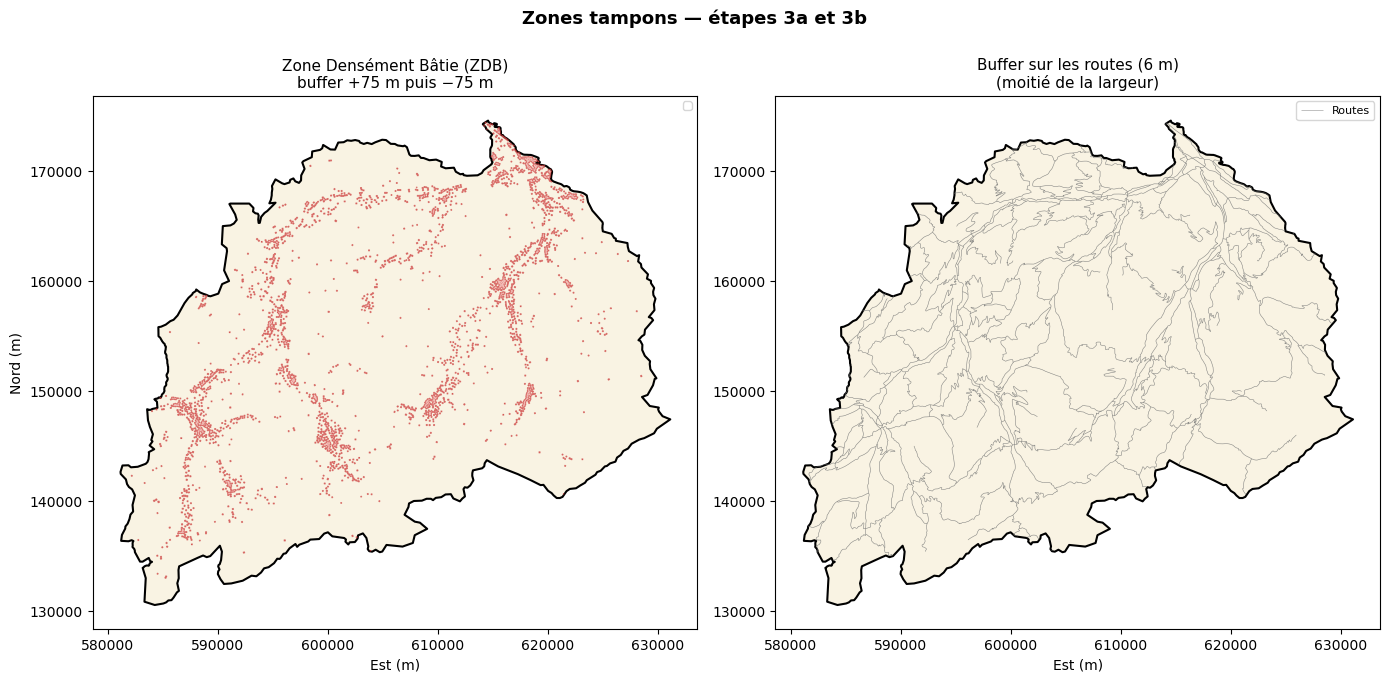

In [5]:
# -------------------------------------------------------
# 3a — Zone Densément Bâtie (ZDB)
#   Étape 1 : buffer +75 m sur les bâtiments, regroupé (unary_union)
#   Étape 2 : buffer −75 m pour éliminer les zones peu denses
# -------------------------------------------------------
print("Étape 1 : buffer +75 m sur les bâtiments (regroupé)...")
buf_pos = buildings_clip.geometry.buffer(75).unary_union   # buffer + dissolve

print("Étape 2 : buffer −75 m pour garder uniquement les zones denses (ZDB)...")
zdb_geom = buf_pos.buffer(-75)
zdb = gpd.GeoDataFrame(geometry=[zdb_geom], crs=CRS_REF)
print(f"  ZDB : aire totale = {zdb_geom.area / 1e6:.2f} km²")

# -------------------------------------------------------
# 3b — Buffer routes (6 m = moitié de la largeur totale de 12 m)
# -------------------------------------------------------
print("\nBuffer routes (6 m)...")
roads_buf_geom = roads_clip.geometry.buffer(6).unary_union
roads_buf = gpd.GeoDataFrame(geometry=[roads_buf_geom], crs=CRS_REF)
print(f"  Routes bufferisées : aire = {roads_buf_geom.area / 1e6:.2f} km²")

# -------------------------------------------------------
# Visualisation
# -------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(14, 7))

study_area.plot(ax=axes[0], facecolor='#f9f3e3', edgecolor='black', linewidth=1.5)
buildings_clip.plot(ax=axes[0], color='#c62828', alpha=0.5, markersize=0.5,
                    label='Bâtiments')
zdb.plot(ax=axes[0], facecolor='#ef9a9a', edgecolor='#c62828',
         linewidth=0.8, alpha=0.5, label='ZDB (±75 m)')
axes[0].set_title('Zone Densément Bâtie (ZDB)\nbuffer +75 m puis −75 m', fontsize=11)
axes[0].legend(fontsize=8)
axes[0].set_xlabel('Est (m)')
axes[0].set_ylabel('Nord (m)')

study_area.plot(ax=axes[1], facecolor='#f9f3e3', edgecolor='black', linewidth=1.5)
roads_clip.plot(ax=axes[1], color='#616161', linewidth=0.4, alpha=0.7,
                label='Routes')
roads_buf.plot(ax=axes[1], facecolor='#b0bec5', edgecolor='none',
               alpha=0.6, label='Buffer routes (6 m)')
axes[1].set_title('Buffer sur les routes (6 m)\n(moitié de la largeur)', fontsize=11)
axes[1].legend(fontsize=8)
axes[1].set_xlabel('Est (m)')

plt.suptitle('Zones tampons — étapes 3a et 3b', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


---
## Partie 3 — Superposition (Union, Différence, Intersection)

Ces outils permettent de combiner plusieurs couches pour créer de nouvelles entités.
C'est l'étape centrale du TP pour produire la **WUI** (Wildland-Urban Interface).

| Outil QGIS | Équivalent Python (shapely) |
|---|---|
| Union | `geom_a.union(geom_b)` |
| Différence | `geom_a.difference(geom_b)` |
| Intersection | `geom_a.intersection(geom_b)` |

### 3.1 Zone Urbaine (ZU) = ZDB ∪ routes (étape 4a)
### 3.2 Zone à risque = Buffer(ZU, 80 m) − ZU (étape 4b)
### 3.3 WUI = zone à risque ∩ Forêt (étape 4c)


4a — Union : ZDB ∪ routes bufferisées → Zone Urbaine (ZU)...
  Zone Urbaine (ZU) : aire = 46.66 km²
4b — Buffer 80 m + Différence → zone de risque incendie...


  Zone à risque (bande 80 m hors ZU) : aire = 233.50 km²
4c — Intersection zone risque ∩ Forêt → WUI...


/tmp/ipykernel_441346/149571014.py:22: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  foret_union = foret_clip.geometry.unary_union


  WUI : aire = 46.21 km²
  WUI représente 15.5 % de la surface forestière


/tmp/ipykernel_441346/149571014.py:45: UserWarning: Legend does not support handles for PatchCollection instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  axes[0].legend(loc='upper right', fontsize=8, title='Couches')
/tmp/ipykernel_441346/149571014.py:45: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[0].legend(loc='upper right', fontsize=8, title='Couches')
/tmp/ipykernel_441346/149571014.py:55: UserWarning: Legend does not support handles for PatchCollection instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  axes[1].legend(loc='upper right', fontsize=8, title='Couches')
/tmp/ipykernel_441346/149571014.py:55: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with

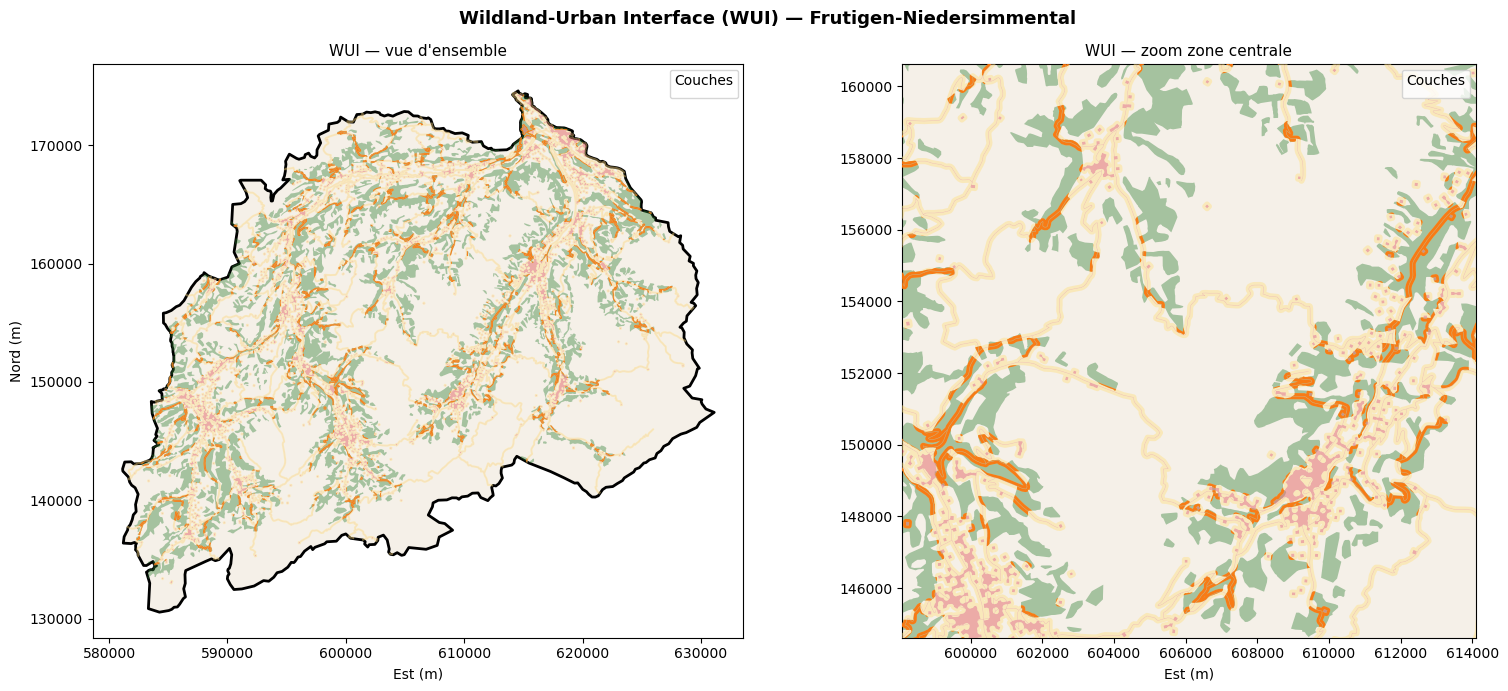

In [6]:
# -------------------------------------------------------
# 4a — Union ZDB ∪ routes bufferisées → Zone Urbaine (ZU)
# -------------------------------------------------------
print("4a — Union : ZDB ∪ routes bufferisées → Zone Urbaine (ZU)...")
zu_geom = zdb_geom.union(roads_buf_geom)
zu = gpd.GeoDataFrame(geometry=[zu_geom], crs=CRS_REF)
print(f"  Zone Urbaine (ZU) : aire = {zu_geom.area / 1e6:.2f} km²")

# -------------------------------------------------------
# 4b — Buffer 80 m autour de ZU + Différence → zone de risque incendie
# -------------------------------------------------------
print("4b — Buffer 80 m + Différence → zone de risque incendie...")
zu_buf_80 = zu_geom.buffer(80)
zone_risque_geom = zu_buf_80.difference(zu_geom)
zone_risque = gpd.GeoDataFrame(geometry=[zone_risque_geom], crs=CRS_REF)
print(f"  Zone à risque (bande 80 m hors ZU) : aire = {zone_risque_geom.area / 1e6:.2f} km²")

# -------------------------------------------------------
# 4c — Intersection zone risque ∩ Forêt → WUI
# -------------------------------------------------------
print("4c — Intersection zone risque ∩ Forêt → WUI...")
foret_union = foret_clip.geometry.unary_union
wui_geom = zone_risque_geom.intersection(foret_union)
wui = gpd.GeoDataFrame(geometry=[wui_geom], crs=CRS_REF)
print(f"  WUI : aire = {wui_geom.area / 1e6:.2f} km²")
print(f"  WUI représente {wui_geom.area / foret_union.area * 100:.1f} % de la surface forestière")

# -------------------------------------------------------
# Carte finale — WUI (vue d'ensemble + zoom)
# -------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

for ax in axes:
    study_area.plot(ax=ax, facecolor='#f5f0e8', edgecolor='black', linewidth=2, zorder=1)
    foret_clip.plot(ax=ax, color='#2e7d32', alpha=0.4, label='Forêt', zorder=2)
    zu.plot(ax=ax, facecolor='#e57373', edgecolor='none', alpha=0.55,
            label='Zone Urbaine (ZU)', zorder=3)
    zone_risque.plot(ax=ax, facecolor='#ffe082', edgecolor='none', alpha=0.45,
                     label='Zone à risque (80 m)', zorder=4)
    wui.plot(ax=ax, facecolor='#ff6d00', edgecolor='none', alpha=0.85,
             label='WUI', zorder=5)

axes[0].set_title('WUI — vue d\'ensemble', fontsize=11)
axes[0].set_xlabel('Est (m)'); axes[0].set_ylabel('Nord (m)')
axes[0].legend(loc='upper right', fontsize=8, title='Couches')

# Zoom au centre pour mieux voir le WUI
b = study_area.total_bounds
cx, cy = (b[0]+b[2])/2, (b[1]+b[3])/2
zoom = 8000
axes[1].set_xlim(cx - zoom, cx + zoom)
axes[1].set_ylim(cy - zoom, cy + zoom)
axes[1].set_title('WUI — zoom zone centrale', fontsize=11)
axes[1].set_xlabel('Est (m)')
axes[1].legend(loc='upper right', fontsize=8, title='Couches')

plt.suptitle('Wildland-Urban Interface (WUI) — Frutigen-Niedersimmental',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


---
## Partie 4 — Régression non-linéaire : polynômes, GLM et GAM

### Pourquoi aller au-delà de la régression linéaire ?

La régression linéaire (OLS) suppose que l'effet de chaque variable explicative est **constant et proportionnel**, et que la variable cible peut prendre n'importe quelle valeur réelle. Ces deux hypothèses sont souvent trop restrictives pour des données réelles — en particulier géographiques : un revenu supplémentaire peut avoir un impact différent selon qu'il s'agit de ménages pauvres ou aisés, et une variable bornée (un pourcentage, un compte) ne se prête pas naturellement à une droite qui peut, en théorie, prendre n'importe quelle valeur.

Cette partie relâche ces hypothèses **progressivement**, en gardant le même jeu de données (Guerry) et la même variable cible (`Litercy`) comme fil conducteur :

| Étape | Ce qui change par rapport à OLS | Section |
|---|---|---|
| **Régression polynomiale** | La relation $x \to y$ n'est plus une droite mais un polynôme — reste un modèle **linéaire dans ses paramètres** | 4.3 |
| **GLM** (*Generalized Linear Model*) | La prédiction est transformée (ex. logit) pour rester dans une plage valide, ici $[0, 100]$ % | 4.4 |
| **GAM** (*Generalized Additive Model*) | Chaque effet $\beta_j x_j$ devient une **fonction lisse** $f_j(x_j)$ apprise depuis les données, sans forme paramétrique imposée | 4.5–4.6 |

Ces fonctions lisses (GAM) sont approximées par des **B-splines** (polynômes par morceaux raccordés) avec une **pénalité de lissage** pour éviter le **surapprentissage** (*overfitting*, voir TP02 §7.4).

### Les données : Guerry (France, années 1830)

Le dataset **Guerry** (Whittaker 2016 — *Crime, suicide, literacy in 19th century France*) contient des statistiques socio-économiques pour les 85 départements français de l'époque :

| Variable | Description |
|---|---|
| **Litercy** | Proportion de conscrits sachant lire et écrire (%) ← **variable cible** |
| **Wealth** | Richesse relative (classement fiscal) |
| **Donatns** | Dons de bienfaisance par habitant |
| **Crm_prp** | Crimes contre la propriété (indice) |
| **Suicids** | Nombre de suicides pour 100 000 hab. |
| **cx, cy** | Coordonnées du centroïde du département |

**Question** : peut-on expliquer le taux d'alphabétisation à partir de ces indicateurs sociaux ? Le lieu géographique joue-t-il un rôle propre au-delà des variables mesurées ?

In [7]:
from geodatasets import get_path
from statsmodels.gam.api import GLMGam, BSplines
import statsmodels.formula.api as smf
from sklearn.preprocessing import SplineTransformer
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import Ridge
from sklearn.model_selection import KFold, cross_val_score
import warnings; warnings.filterwarnings('ignore')

# Chargement via geodatasets (pas de fichier local nécessaire)
guerry = gpd.read_file(get_path('geoda.guerry'))
guerry['cx'] = guerry.geometry.centroid.x
guerry['cy'] = guerry.geometry.centroid.y

target   = 'Litercy'
features = ['Wealth', 'Donatns', 'Crm_prp']
labels   = ['Richesse', 'Dons\nbienfaisance', 'Crimes\n(propriété)']

y    = guerry[target].values
X_th = guerry[features].values
X_sp = guerry[features + ['cx', 'cy']].values

print(f"Guerry : {len(guerry)} départements | CRS : {guerry.crs}\n")
print(guerry[[target] + features + ['Suicids']].describe().round(1).to_string())

Guerry : 85 départements | CRS : EPSG:27572

       Litercy  Wealth  Donatns  Crm_prp   Suicids
count     85.0    85.0     85.0     85.0      85.0
mean      39.1    43.6   6723.3   7881.3   36516.8
std       17.4    25.1   4863.2   3048.6   31498.3
min       12.0     1.0   1246.0   1368.0    3460.0
25%       25.0    22.0   3446.0   5990.0   15400.0
50%       38.0    44.0   4964.0   7624.0   26198.0
75%       52.0    65.0   9242.0   9190.0   45180.0
max       74.0    86.0  27830.0  20235.0  163241.0


/home/jsoutter/anaconda3/envs/landslide/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### 4.1 Exploration — carte et corrélations

Avant de modéliser, on visualise la **distribution spatiale** de l'alphabétisation et les **corrélations** entre variables. La carte révèle d'emblée un fort gradient géographique (nord-est vs sud-ouest), qui motivera l'ajout d'un lisseur spatial.

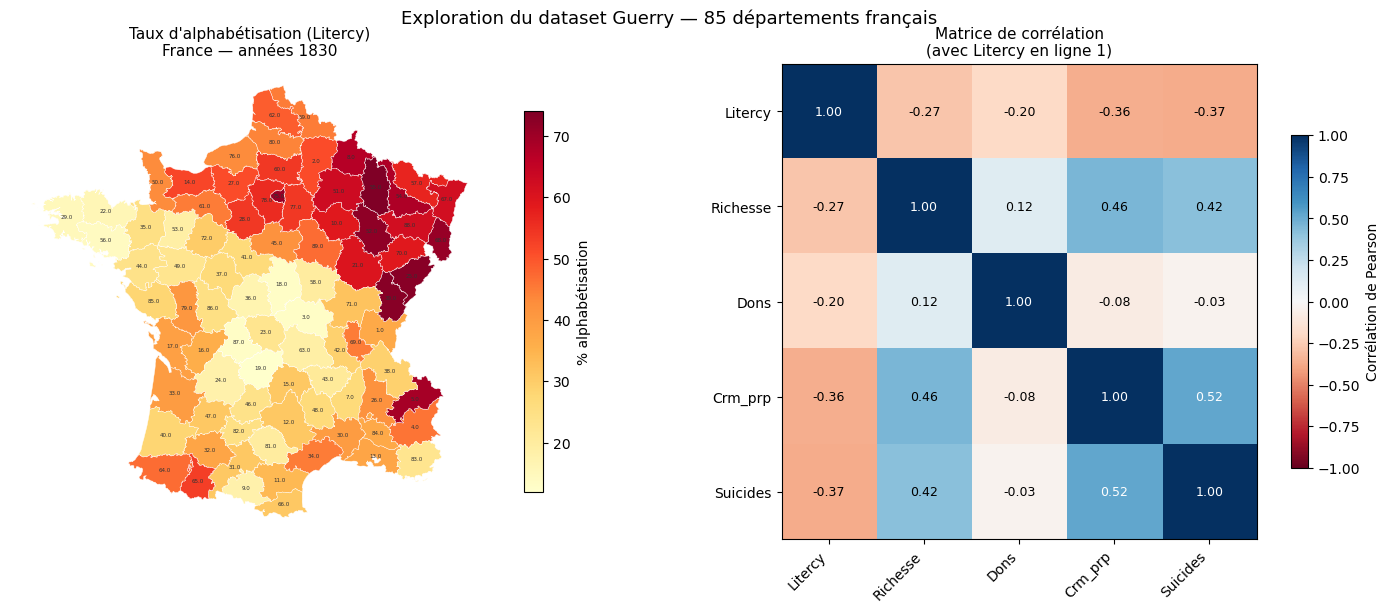

In [8]:
vars_corr = [target] + features + ['Suicids']
corr = guerry[vars_corr].corr()

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Carte choroplèthe : alphabétisation
guerry.plot(ax=axes[0], column=target, cmap='YlOrRd',
            legend=True, legend_kwds={'label': "% alphabétisation", 'shrink': 0.8},
            edgecolor='white', linewidth=0.3)
axes[0].set_title("Taux d'alphabétisation (Litercy)\nFrance — années 1830", fontsize=11)
axes[0].set_axis_off()
# Ajouter les noms de régions aux centroïdes
for _, row in guerry.iterrows():
    axes[0].text(row['cx'], row['cy'], row['dept'],
                 ha='center', va='center', fontsize=4, color='#333')

# Matrice de corrélation
im = axes[1].imshow(corr, cmap='RdBu', vmin=-1, vmax=1)
tick_labels = ['Litercy', 'Richesse', 'Dons', 'Crm_prp', 'Suicides']
axes[1].set_xticks(range(len(vars_corr))); axes[1].set_xticklabels(tick_labels, rotation=45, ha='right')
axes[1].set_yticks(range(len(vars_corr))); axes[1].set_yticklabels(tick_labels)
for i in range(len(vars_corr)):
    for j in range(len(vars_corr)):
        axes[1].text(j, i, f"{corr.iloc[i, j]:.2f}",
                     ha='center', va='center', fontsize=9,
                     color='white' if abs(corr.iloc[i, j]) > 0.5 else 'black')
plt.colorbar(im, ax=axes[1], shrink=0.7, label='Corrélation de Pearson')
axes[1].set_title("Matrice de corrélation\n(avec Litercy en ligne 1)", fontsize=11)

plt.suptitle("Exploration du dataset Guerry — 85 départements français", fontsize=13)
plt.tight_layout()
plt.show()

### 4.2 Référence : régression linéaire (OLS)

On commence par un modèle de référence — la régression linéaire multiple OLS — qui suppose une relation linéaire entre chaque variable explicative et l'alphabétisation. Le R² sera notre baseline à améliorer.

OLS — R² = 0.190  |  R² adj. = 0.160

                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     62.3039      5.609     11.108      0.000      51.144      73.464
Wealth        -0.0660      0.079     -0.832      0.408      -0.224       0.092
Donatns       -0.0008      0.000     -2.081      0.041      -0.001   -3.34e-05
Crm_prp       -0.0019      0.001     -2.954      0.004      -0.003      -0.001


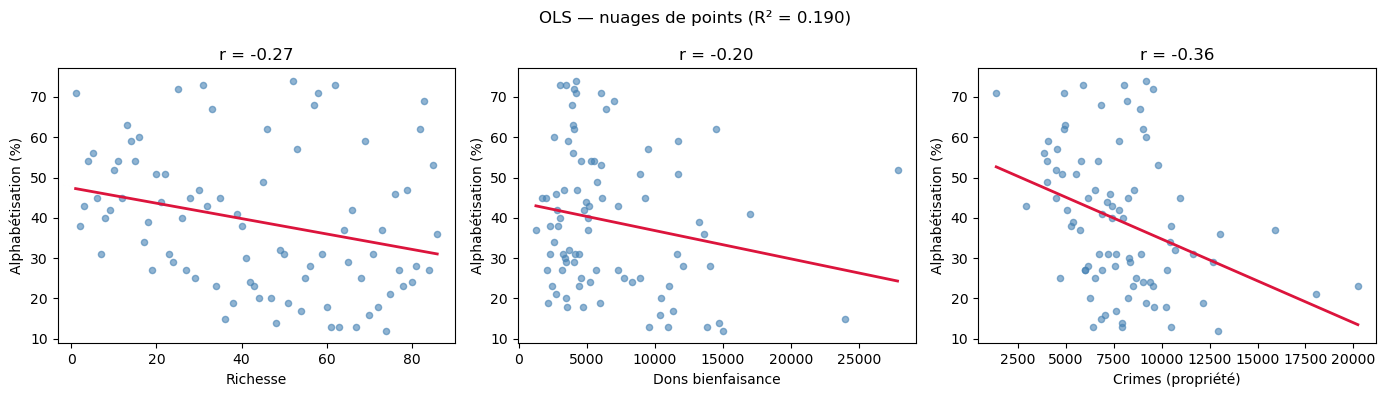

In [9]:
ols = smf.ols('Litercy ~ Wealth + Donatns + Crm_prp', data=guerry).fit()
print(f"OLS — R² = {ols.rsquared:.3f}  |  R² adj. = {ols.rsquared_adj:.3f}\n")
print(ols.summary().tables[1])

# Nuages de points de chaque prédicteur vs cible
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
from scipy.stats import pearsonr
for ax, feat, label in zip(axes, features, labels):
    x = guerry[feat].values
    r_val, _ = pearsonr(x, y)
    ax.scatter(x, y, s=20, alpha=0.6, color='steelblue')
    m, b = np.polyfit(x, y, 1)
    ax.plot(np.sort(x), m * np.sort(x) + b, color='crimson', linewidth=2)
    ax.set_xlabel(label.replace('\n', ' '))
    ax.set_ylabel('Alphabétisation (%)')
    ax.set_title(f'r = {r_val:.2f}')

plt.suptitle(f"OLS — nuages de points (R² = {ols.rsquared:.3f})", fontsize=12)
plt.tight_layout()
plt.show()

### 4.3 Régression polynomiale

La régression polynomiale remplace la droite $\hat{y} = \beta_0 + \beta_1 x$ par un polynôme

$$\hat{y} = \beta_0 + \beta_1 x + \beta_2 x^2 + \cdots + \beta_d x^d$$

Malgré son nom, c'est toujours un **modèle linéaire** au sens statistique : linéaire par rapport aux paramètres $\beta_j$ (on peut l'ajuster avec `np.polyfit`, ou une régression OLS sur les colonnes $x, x^2, \ldots, x^d$). Seule la relation entre $x$ et $y$ devient non-linéaire.

Le **degré** $d$ contrôle la flexibilité : $d=1$ est la droite OLS ; un $d$ élevé peut capturer des courbures fines, mais risque le **surapprentissage**, d'autant plus que le dataset Guerry ne compte que 85 départements.

On illustre sur un seul prédicteur (`Wealth`), en ajustant sur un **petit sous-échantillon de 20 départements** (même dispositif qu'au TP02 §7.4, pour rendre le surapprentissage visible) et en évaluant sur les 65 restants, jamais vus lors de l'ajustement.

Degré   R² (entraînement, n=20)   R² (reste, jamais vu)   
1       0.165                     0.008                   
8       0.530                     -0.460                  


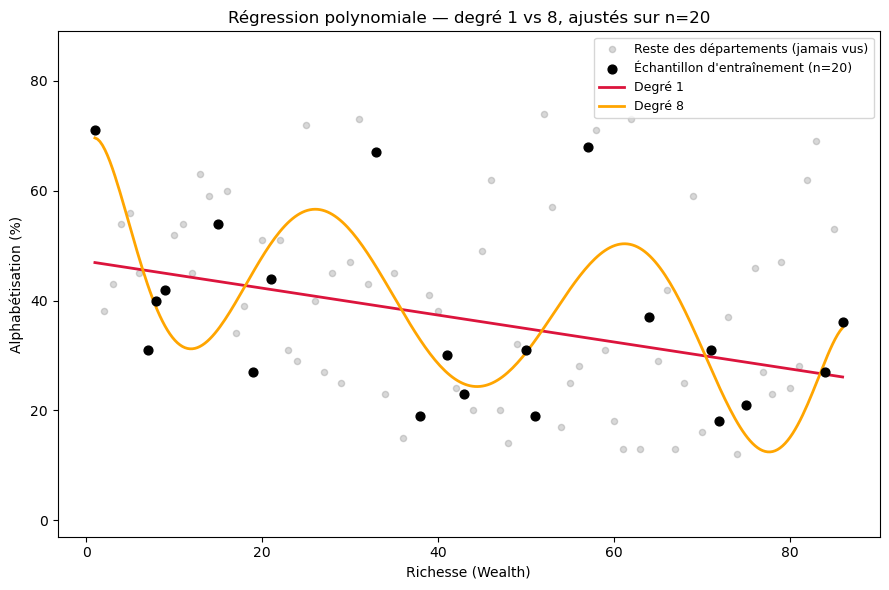


Le degré 8 explique beaucoup mieux les 20 points d'entraînement que la droite,
mais son R² sur les données jamais vues devient négatif : il a appris le bruit de
cet échantillon précis (courbe qui oscille), pas une vraie tendance généralisable.


In [10]:
x_w = guerry['Wealth'].values
y_w = guerry['Litercy'].values

rng = np.random.default_rng(42)
sample_idx = rng.choice(len(x_w), size=20, replace=False)
rest_idx   = np.setdiff1d(np.arange(len(x_w)), sample_idx)
x_tr, y_tr = x_w[sample_idx], y_w[sample_idx]
x_te, y_te = x_w[rest_idx],   y_w[rest_idx]

degrees = [1, 8]
x_line = np.linspace(x_w.min(), x_w.max(), 300)

fig, ax = plt.subplots(figsize=(9, 6))
ax.scatter(x_te, y_te, alpha=0.3, s=20, color='grey', label='Reste des départements (jamais vus)')
ax.scatter(x_tr, y_tr, s=40, color='black', zorder=5, label="Échantillon d'entraînement (n=20)")

print(f"{'Degré':<8}{'R² (entraînement, n=20)':<26}{'R² (reste, jamais vu)':<24}")
for deg, color in zip(degrees, ['crimson', 'orange']):
    coeffs = np.polyfit(x_tr, y_tr, deg)
    ax.plot(x_line, np.polyval(coeffs, x_line), color=color, linewidth=2, label=f'Degré {deg}')
    r2_tr = r2_score(y_tr, np.polyval(coeffs, x_tr))
    r2_te = r2_score(y_te, np.polyval(coeffs, x_te))
    print(f"{deg:<8}{r2_tr:<26.3f}{r2_te:<24.3f}")

ax.set_ylim(y_w.min() - 15, y_w.max() + 15)
ax.set_xlabel('Richesse (Wealth)'); ax.set_ylabel('Alphabétisation (%)')
ax.legend(fontsize=9)
ax.set_title('Régression polynomiale — degré 1 vs 8, ajustés sur n=20')
plt.tight_layout()
plt.show()

print("\nLe degré 8 explique beaucoup mieux les 20 points d'entraînement que la droite,")
print("mais son R² sur les données jamais vues devient négatif : il a appris le bruit de")
print("cet échantillon précis (courbe qui oscille), pas une vraie tendance généralisable.")

### 4.4 GLM — un modèle adapté aux pourcentages

`Litercy` est un **pourcentage**, donc borné entre 0 et 100. Rien ne garantit pourtant qu'une droite OLS ajustée sur des valeurs entre 0 et 100 y reste une fois extrapolée à des prédicteurs extrêmes, ce qui n'aurait pas de sens pour un taux.

Un **GLM** (*Generalized Linear Model*) règle ce problème en ne travaillant plus directement sur le pourcentage, mais sur une **transformation** de celui-ci. Avec la transformation **logit**, on modélise :

$$\ln\!\left(\frac{p}{1-p}\right) = \beta_0 + \beta_1 \cdot \text{Wealth} + \beta_2 \cdot \text{Donatns} + \beta_3 \cdot \text{Crm\_prp}$$

où $p$ est la proportion prédite (`Litercy` / 100). Le membre de gauche — le *logit* de $p$ — peut prendre n'importe quelle valeur réelle, donc la combinaison linéaire à droite s'ajuste comme dans un OLS classique. Mais dès qu'on **inverse** la transformation pour revenir à $p$, le résultat est mathématiquement garanti de rester entre 0 et 1 : la prédiction en pourcentage reste donc toujours dans $[0, 100]$, quels que soient les prédicteurs.

In [11]:
import statsmodels.api as sm
import pandas as pd

guerry['Litercy_prop'] = guerry['Litercy'] / 100   # proportion dans (0, 1) pour le GLM binomial

glm = smf.glm('Litercy_prop ~ Wealth + Donatns + Crm_prp', data=guerry,
              family=sm.families.Binomial()).fit()

pred_glm_all = glm.predict(guerry) * 100   # retour à l'échelle % pour comparer à OLS
r2_glm = r2_score(guerry['Litercy'], pred_glm_all)

print(f"OLS — R² = {ols.rsquared:.3f}")
print(f"GLM — R² = {r2_glm:.3f}  (sur l'échelle % après transformation logistique inverse)")

# --- Le vrai intérêt du GLM : un point de prédicteurs extrêmes, hors du nuage observé ---
extreme = pd.DataFrame({
    'Wealth':   [guerry['Wealth'].max() * 3],
    'Donatns':  [guerry['Donatns'].min()],
    'Crm_prp':  [guerry['Crm_prp'].max() * 2],
})
pred_ols_extreme = ols.predict(extreme).iloc[0]
pred_glm_extreme = (glm.predict(extreme) * 100).iloc[0]

print(f"\nExtrapolation à des valeurs de prédicteurs extrêmes (hors du nuage observé) :")
print(f"  OLS  → Litercy prédite = {pred_ols_extreme:6.1f} %   {'⚠ hors de [0,100] !' if not 0 <= pred_ols_extreme <= 100 else ''}")
print(f"  GLM  → Litercy prédite = {pred_glm_extreme:6.1f} %   (toujours dans [0,100] par construction)")

OLS — R² = 0.190
GLM — R² = 0.198  (sur l'échelle % après transformation logistique inverse)

Extrapolation à des valeurs de prédicteurs extrêmes (hors du nuage observé) :
  OLS  → Litercy prédite =  -33.6 %   ⚠ hors de [0,100] !
  GLM  → Litercy prédite =    2.3 %   (toujours dans [0,100] par construction)


### 4.5 GAM thématique — splines sur variables sociales

Un **GAM** remplace la droite de régression de chaque prédicteur par une **courbe lisse** (B-spline). Cela permet de capturer des relations non-linéaires, par exemple un effet de richesse qui diminue au-delà d'un certain seuil.

La pénalité de lissage (`alpha`) contrôle la souplesse de la courbe : plus `alpha` est grand, plus la courbe se rapproche d'une droite. En `statsmodels`, le GAM utilise des B-splines pénalisées (P-splines).

Le **graphe d'effets partiels** (`plot_partial`) montre la contribution de chaque variable à la prédiction, toutes choses égales par ailleurs.

GAM thématique — R² = 0.259  (vs OLS : 0.190)


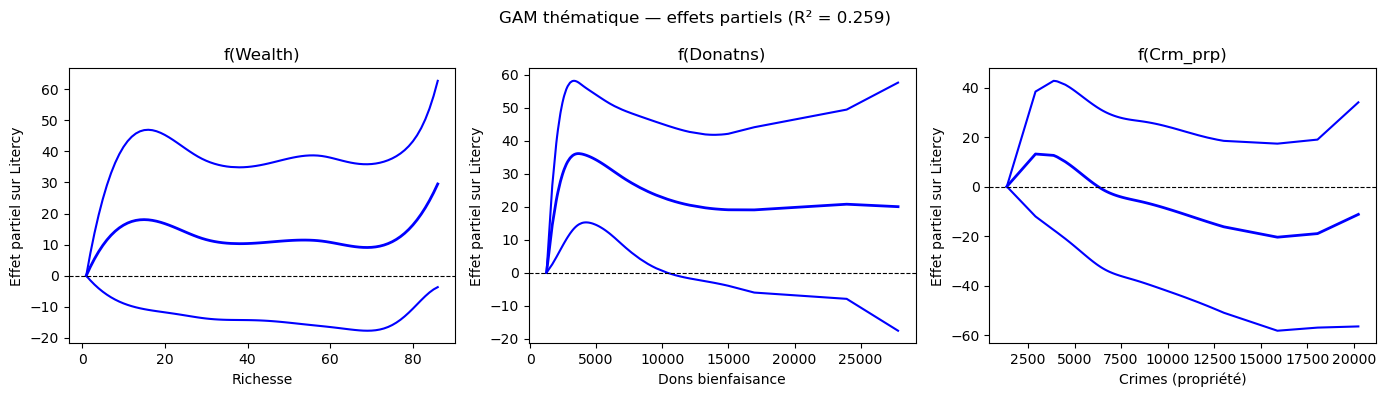

In [12]:
# Base de B-splines pour les 3 variables thématiques
# df=6 : 6 fonctions de base par variable ; degree=3 : splines cubiques
bs_th = BSplines(X_th, df=[6, 6, 6], degree=[3, 3, 3])

# Ajustement du GAM avec pénalité de lissage (alpha = [1, 1, 1])
gam_th = GLMGam(y, smoother=bs_th, alpha=[1, 1, 1]).fit()
r2_gam_th = r2_score(y, gam_th.fittedvalues)
print(f"GAM thématique — R² = {r2_gam_th:.3f}  (vs OLS : {ols.rsquared:.3f})")

# Effets partiels : contribution de chaque variable lisse
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for i, (ax, label) in enumerate(zip(axes, labels)):
    gam_th.plot_partial(i, ax=ax, plot_se=True)
    ax.set_xlabel(label.replace('\n', ' '))
    ax.set_ylabel('Effet partiel sur Litercy')
    ax.set_title(f'f({features[i]})')
    ax.axhline(0, color='k', linewidth=0.8, linestyle='--')

plt.suptitle(f"GAM thématique — effets partiels (R² = {r2_gam_th:.3f})", fontsize=12)
plt.tight_layout()
plt.show()

### 4.6 GAM spatial — ajouter un lisseur géographique

La carte de l'alphabétisation montrait un **gradient géographique marqué** (nord-est alphabétisé vs sud-ouest peu alphabétisé). Ce gradient n'est pas capturé par les variables thématiques seules.

On l'intègre en ajoutant un **lisseur spatial 2D** : $f(cx, cy)$ — une surface lisse sur les coordonnées des centroïdes départementaux. Cela équivaut à modéliser l'autocorrélation spatiale résiduelle.

$$\hat{\text{Litercy}} = \beta_0 + f_1(\text{Wealth}) + f_2(\text{Donatns}) + f_3(\text{Crm\_prp}) + f_4(cx, cy)$$

Le lisseur spatial est ajusté avec une pénalité plus faible (`alpha` plus petit) pour lui permettre de capturer des gradients larges.

OLS               R² = 0.190
GAM thématique    R² = 0.259
GAM spatial       R² = 0.787  ← forte amélioration due au lisseur géographique


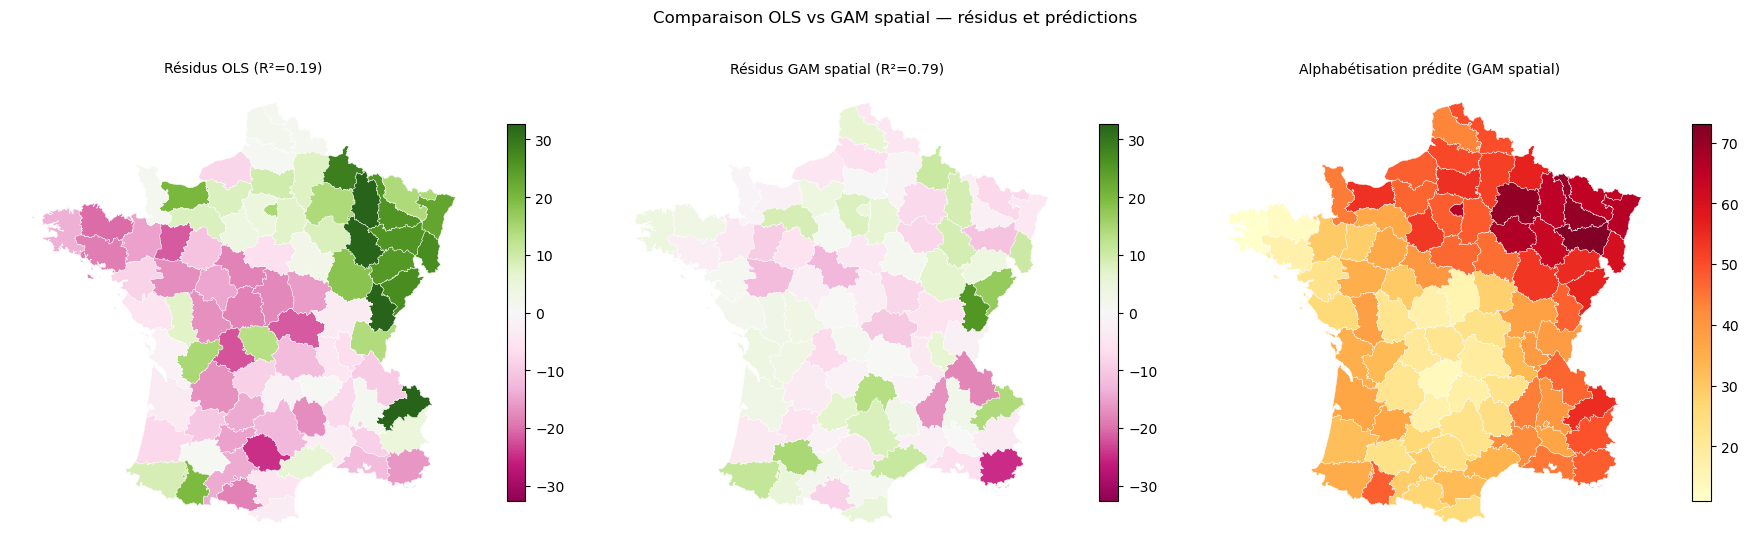

In [13]:
# Base de B-splines : variables thématiques + coordonnées spatiales
# Les centroïdes (cx, cy) reçoivent plus de fonctions de base (df=8)
# et une pénalité plus faible (alpha=1e-3) pour capturer le gradient spatial
bs_sp = BSplines(X_sp, df=[6, 6, 6, 8, 8], degree=[3, 3, 3, 3, 3])
gam_sp = GLMGam(y, smoother=bs_sp, alpha=[1, 1, 1, 1e-3, 1e-3]).fit()
r2_gam_sp = r2_score(y, gam_sp.fittedvalues)

print(f"OLS               R² = {ols.rsquared:.3f}")
print(f"GAM thématique    R² = {r2_gam_th:.3f}")
print(f"GAM spatial       R² = {r2_gam_sp:.3f}  ← forte amélioration due au lisseur géographique")

# Résidus OLS vs GAM spatial
guerry['resid_ols'] = y - ols.predict(guerry)
guerry['resid_gam'] = y - gam_sp.fittedvalues
guerry['pred_gam']  = gam_sp.fittedvalues

vabs = np.percentile(np.abs(guerry['resid_ols']), 97)

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
for ax, col, title, cmap, sym in [
    (axes[0], 'resid_ols', f'Résidus OLS (R²={ols.rsquared:.2f})',     'PiYG', True),
    (axes[1], 'resid_gam', f'Résidus GAM spatial (R²={r2_gam_sp:.2f})','PiYG', True),
    (axes[2], 'pred_gam',  'Alphabétisation prédite (GAM spatial)',      'YlOrRd', False),
]:
    kw = dict(vmin=-vabs, vmax=vabs) if sym else {}
    guerry.plot(ax=ax, column=col, cmap=cmap, legend=True,
                legend_kwds={'shrink': 0.7}, edgecolor='white', linewidth=0.3, **kw)
    ax.set_title(title, fontsize=10)
    ax.set_axis_off()

plt.suptitle("Comparaison OLS vs GAM spatial — résidus et prédictions", fontsize=12)
plt.tight_layout()
plt.show()

### 4.7 Validation croisée K-fold

Les R² vus jusqu'ici (OLS, polynomiale, GLM, GAM) sont pour la plupart calculés **sur les mêmes données** que celles utilisées pour l'ajustement : ils sont **optimistes**. Un modèle plus complexe peut avoir un R² d'entraînement élevé tout en généralisant mal à de nouvelles observations (*surapprentissage*) — on vient de le voir de façon spectaculaire avec le polynôme de degré 8 (§4.3).

La **validation croisée à K plis** (K-fold CV) fournit une estimation honnête, applicable uniformément aux cinq modèles :
1. Diviser les 85 départements en K=5 groupes (*plis*)
2. Pour chaque pli : entraîner sur les 4 autres, évaluer sur celui-ci
3. Moyenner les R² des 5 plis

Pour que la CV fonctionne avec les GAM, on utilise un pipeline sklearn équivalent :
`SplineTransformer` (base B-spline, knots sur quantiles) + `Ridge` (pénalisation L₂ ≈ pénalité de lissage). Le GLM n'a pas de wrapper scikit-learn standard : sa CV est effectuée manuellement, pli par pli, avec `statsmodels`.

> **Résultat attendu** : le GAM thématique peut *surapprendre* avec seulement 68 points d'entraînement et 18 paramètres de splines — la régression polynomiale (même à un degré modéré, sur 3 variables) aussi. Le GAM spatial, malgré plus de paramètres, capture un **effet géographique réel** qui se révèle dans le CV.

In [14]:
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures

kf = KFold(n_splits=5, shuffle=True, random_state=42)

# 1. OLS (référence linéaire)
r2_cv_ols = cross_val_score(LinearRegression(), X_th, y, cv=kf, scoring='r2')

# 2. Régression polynomiale (degré 2, sur les 3 variables thématiques)
pipe_poly = make_pipeline(PolynomialFeatures(degree=2, include_bias=False), LinearRegression())
r2_cv_poly = cross_val_score(pipe_poly, X_th, y, cv=kf, scoring='r2')
r2_poly_train = r2_score(y, pipe_poly.fit(X_th, y).predict(X_th))

# 3. GLM (binomial, lien logit) — pas de wrapper scikit-learn standard : CV manuelle
r2_cv_glm = []
for tr_idx, te_idx in kf.split(X_th):
    train_df, test_df = guerry.iloc[tr_idx], guerry.iloc[te_idx]
    glm_fold = smf.glm('Litercy_prop ~ Wealth + Donatns + Crm_prp',
                        data=train_df, family=sm.families.Binomial()).fit()
    pred_fold = glm_fold.predict(test_df) * 100
    r2_cv_glm.append(r2_score(test_df['Litercy'], pred_fold))
r2_cv_glm = np.array(r2_cv_glm)

# 4. GAM thématique ≈ SplineTransformer + Ridge (pénalité L2 ≈ pénalité de lissage)
pipe_th = make_pipeline(
    SplineTransformer(n_knots=5, degree=3, knots='quantile'),
    Ridge(alpha=10)
)
r2_cv_gam_th = cross_val_score(pipe_th, X_th, y, cv=kf, scoring='r2')

# 5. GAM spatial ≈ SplineTransformer + Ridge sur [thématique + cx, cy]
pipe_sp = make_pipeline(
    SplineTransformer(n_knots=5, degree=3, knots='quantile'),
    Ridge(alpha=0.1)
)
r2_cv_gam_sp = cross_val_score(pipe_sp, X_sp, y, cv=kf, scoring='r2')

# Tableau récapitulatif
import pandas as pd
results = pd.DataFrame({
    'Modèle':           ['OLS', 'Polynomial (deg. 2)', 'GLM (binomial, logit)', 'GAM thématique', 'GAM spatial'],
    'R² entraînement':  [ols.rsquared, r2_poly_train, r2_glm, r2_gam_th, r2_gam_sp],
    'R² CV (5-fold)':   [r2_cv_ols.mean(), r2_cv_poly.mean(), r2_cv_glm.mean(), r2_cv_gam_th.mean(), r2_cv_gam_sp.mean()],
    '± (écart-type)':   [r2_cv_ols.std(),  r2_cv_poly.std(),  r2_cv_glm.std(),  r2_cv_gam_th.std(),  r2_cv_gam_sp.std()],
}).round(3)

print(results.to_string(index=False))
print()
print("⚠ Polynomial (deg. 2) : R² entraînement ≫ R² CV, parfois négatif → surapprentissage net,")
print("  malgré un degré modéré — la combinatoire des termes croisés (10 paramètres pour 3")
print("  variables) épuise vite les 85 observations.")
print("⚠ GAM thématique : R² entraînement > R² CV → surapprentissage")
print("✓ GLM : légère amélioration sur OLS, sans complexité supplémentaire majeure")
print("✓ GAM spatial : R² CV élevé → gradient géographique réel et généralisable")

               Modèle  R² entraînement  R² CV (5-fold)  ± (écart-type)
                  OLS            0.190           0.132           0.086
  Polynomial (deg. 2)            0.244          -0.028           0.344
GLM (binomial, logit)            0.198           0.150           0.091
       GAM thématique            0.259           0.109           0.093
          GAM spatial            0.787           0.501           0.053

⚠ Polynomial (deg. 2) : R² entraînement ≫ R² CV, parfois négatif → surapprentissage net,
  malgré un degré modéré — la combinatoire des termes croisés (10 paramètres pour 3
  variables) épuise vite les 85 observations.
⚠ GAM thématique : R² entraînement > R² CV → surapprentissage
✓ GLM : légère amélioration sur OLS, sans complexité supplémentaire majeure
✓ GAM spatial : R² CV élevé → gradient géographique réel et généralisable


### 4.8 Incertitude liée au découpage — validation croisée répétée

Le tableau précédent donne **une seule valeur** de R² CV par modèle — celle obtenue avec `random_state=42`. Mais avec seulement **85 départements**, répartis aléatoirement en 5 plis de ~17 observations, le découpage lui-même est une source de variabilité : un autre tirage aléatoire donnerait un R² CV légèrement différent, simplement parce que les plis contiendraient des départements différents.

On répète la validation croisée **20 fois**, avec un `random_state` différent à chaque fois, pour visualiser la **distribution** du R² CV plutôt qu'un seul chiffre. Plus le jeu de données est petit, plus cette variabilité est grande — un avertissement à garder en tête chaque fois qu'on compare deux R² CV calculés une seule fois.

> ⚠️ Ce n'est **pas** du bootstrap, même si les deux techniques « répètent une procédure aléatoire plusieurs fois » : ici, on ré-utilise toujours les **85 mêmes départements**, seul le *découpage* en plis change. Le bootstrap (§4.9) tire un **nouvel échantillon** de départements à chaque répétition — une question différente.

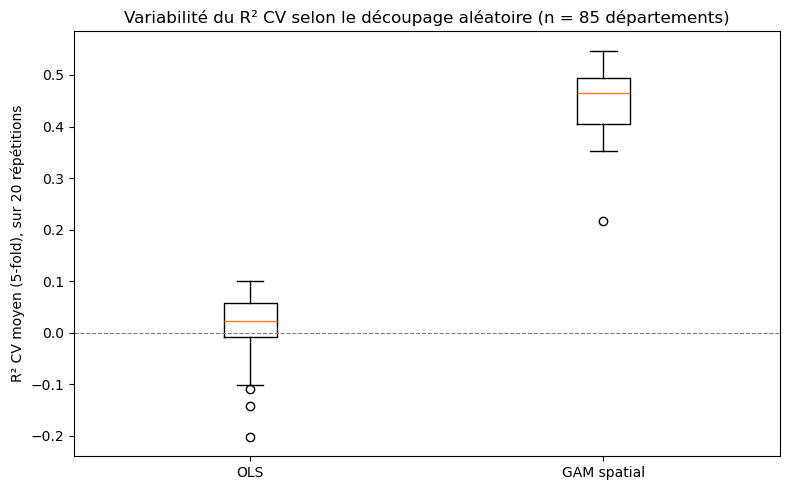

OLS         : R² CV = 0.005 ± 0.081  (plage -0.202 – 0.101)
GAM spatial : R² CV = 0.448 ± 0.077  (plage 0.216 – 0.547)

Le R² CV de l'OLS (§4.7 : 0.132 pour random_state=42) n'était pas représentatif :
en moyenne sur 20 tirages, il tombe près de 0 et peut même devenir négatif — le lien
linéaire entre les 3 variables thématiques et Litercy est faible et instable avec n=85.
Le GAM spatial, lui, reste nettement positif sur TOUS les tirages : son avantage
(le gradient géographique) est robuste au découpage, pas un artefact d'un seul essai.


In [15]:
n_repeats = 20
r2_repeats_ols    = []
r2_repeats_gam_sp = []
for seed in range(n_repeats):
    kf_r = KFold(n_splits=5, shuffle=True, random_state=seed)
    r2_repeats_ols.append(cross_val_score(LinearRegression(), X_th, y, cv=kf_r, scoring='r2').mean())
    r2_repeats_gam_sp.append(cross_val_score(pipe_sp, X_sp, y, cv=kf_r, scoring='r2').mean())

r2_repeats_ols    = np.array(r2_repeats_ols)
r2_repeats_gam_sp = np.array(r2_repeats_gam_sp)

fig, ax = plt.subplots(figsize=(8, 5))
ax.boxplot([r2_repeats_ols, r2_repeats_gam_sp], tick_labels=['OLS', 'GAM spatial'])
ax.axhline(0, color='grey', linewidth=0.8, linestyle='--')
ax.set_ylabel(f'R² CV moyen (5-fold), sur {n_repeats} répétitions')
ax.set_title(f'Variabilité du R² CV selon le découpage aléatoire (n = {len(y)} départements)')

plt.tight_layout()
plt.show()

print(f"OLS         : R² CV = {r2_repeats_ols.mean():.3f} ± {r2_repeats_ols.std():.3f}  "
      f"(plage {r2_repeats_ols.min():.3f} – {r2_repeats_ols.max():.3f})")
print(f"GAM spatial : R² CV = {r2_repeats_gam_sp.mean():.3f} ± {r2_repeats_gam_sp.std():.3f}  "
      f"(plage {r2_repeats_gam_sp.min():.3f} – {r2_repeats_gam_sp.max():.3f})")
print()
print("Le R² CV de l'OLS (§4.7 : 0.132 pour random_state=42) n'était pas représentatif :")
print("en moyenne sur 20 tirages, il tombe près de 0 et peut même devenir négatif — le lien")
print("linéaire entre les 3 variables thématiques et Litercy est faible et instable avec n=85.")
print("Le GAM spatial, lui, reste nettement positif sur TOUS les tirages : son avantage")
print("(le gradient géographique) est robuste au découpage, pas un artefact d'un seul essai.")

### 4.9 Bootstrap — intervalle de confiance par ré-échantillonnage

La CV répétée (§4.8) fait varier le **découpage** en plis, mais utilise toujours les mêmes 85 départements. Le **bootstrap** répond à une question différente : si on avait observé un *autre échantillon* de départements français du XIXe siècle (même processus, tirage différent), quelle serait la variabilité du R² ?

Le principe : tirer, $B$ fois, un nouvel échantillon de 85 départements **avec remise** depuis les données observées (certains départements apparaissent plusieurs fois, d'autres pas du tout), ré-ajuster le modèle sur chaque tirage, et regarder la distribution des R² obtenus. Pour que chaque réplication reste une évaluation **hors échantillon** (et non optimiste comme un R² d'entraînement), on évalue chaque modèle sur les départements **jamais tirés** dans cette réplication — les points *out-of-bag* (OOB), qui représentent en moyenne environ 37 % de l'échantillon original.

> Bootstrap et CV répétée sont deux outils **complémentaires**, pas concurrents, pour quantifier l'incertitude d'un R² : la CV répétée mesure l'incertitude due au **découpage** train/test ; le bootstrap mesure l'incertitude due à l'**échantillonnage** de la population source. Dans un projet réel, les deux questions sont légitimes, et rien n'empêche de les utiliser ensemble.

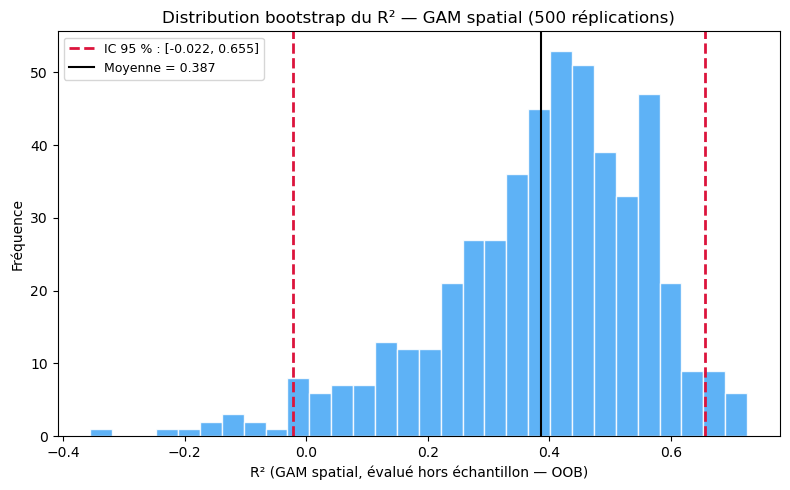

R² bootstrap (OOB) : moyenne = 0.387  écart-type = 0.174
Intervalle de confiance à 95 % : [-0.022, 0.655]

Comparaison avec la CV répétée (§4.8, GAM spatial) : moyenne ≈ 0.448, plage 0.216–0.547.
Le bootstrap donne un intervalle plus large : il inclut l'incertitude due au fait que nos 85
départements ne sont eux-mêmes qu'UN échantillon parmi d'autres possibles — une source de
variabilité que la CV répétée, qui réutilise toujours les mêmes 85 départements, ne capture pas.


In [16]:
n_boot = 500
n = len(guerry)
rng_boot = np.random.default_rng(1)

r2_boot = []
for _ in range(n_boot):
    boot_idx = rng_boot.integers(0, n, size=n)          # tirage avec remise (même taille que l'original)
    oob_idx  = np.setdiff1d(np.arange(n), boot_idx)     # départements jamais tirés (hors échantillon)
    if len(oob_idx) < 5:
        continue   # cas rare : trop peu de points OOB pour évaluer

    pipe_boot = make_pipeline(SplineTransformer(n_knots=5, degree=3, knots='quantile'), Ridge(alpha=0.1))
    pipe_boot.fit(X_sp[boot_idx], y[boot_idx])
    r2_boot.append(r2_score(y[oob_idx], pipe_boot.predict(X_sp[oob_idx])))

r2_boot = np.array(r2_boot)
ci_low, ci_high = np.percentile(r2_boot, [2.5, 97.5])

fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(r2_boot, bins=30, color='#42a5f5', alpha=0.85, edgecolor='white')
ax.axvline(ci_low,  color='crimson', linestyle='--', linewidth=2)
ax.axvline(ci_high, color='crimson', linestyle='--', linewidth=2,
           label=f'IC 95 % : [{ci_low:.3f}, {ci_high:.3f}]')
ax.axvline(r2_boot.mean(), color='black', linewidth=1.5, label=f'Moyenne = {r2_boot.mean():.3f}')
ax.set_xlabel('R² (GAM spatial, évalué hors échantillon — OOB)')
ax.set_ylabel('Fréquence')
ax.set_title(f'Distribution bootstrap du R² — GAM spatial ({len(r2_boot)} réplications)')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

print(f"R² bootstrap (OOB) : moyenne = {r2_boot.mean():.3f}  écart-type = {r2_boot.std():.3f}")
print(f"Intervalle de confiance à 95 % : [{ci_low:.3f}, {ci_high:.3f}]")
print()
print("Comparaison avec la CV répétée (§4.8, GAM spatial) : moyenne ≈ 0.448, plage 0.216–0.547.")
print("Le bootstrap donne un intervalle plus large : il inclut l'incertitude due au fait que nos 85")
print("départements ne sont eux-mêmes qu'UN échantillon parmi d'autres possibles — une source de")
print("variabilité que la CV répétée, qui réutilise toujours les mêmes 85 départements, ne capture pas.")

---
## Récapitulatif

### Parties 1–3 — Géotraitement vectoriel (parallèle du TP QGIS 3)

| Opération QGIS | Code Python clé |
|---|---|
| Sélection par expression | `gdf[gdf['col'].str.contains(...)]` |
| Fusionner (dissolve) | `gdf.dissolve()` |
| Couper (Clip) | `gpd.clip(layer, mask)` |
| Zone tampon (Buffer) | `.buffer(dist)` + `.unary_union` |
| Double buffer (ZDB) | `.buffer(+75).unary_union` puis `.buffer(-75)` |
| Union / Différence / Intersection | `geom_a.union/difference/intersection(geom_b)` |

### Partie 4 — Régression non-linéaire : polynômes, GLM et GAM

| Étape | Code clé |
|---|---|
| Charger données spatiales | `gpd.read_file(get_path('geoda.guerry'))` |
| Centroïdes | `.geometry.centroid.x` / `.y` |
| Baseline OLS | `smf.ols('y ~ x1 + x2', data=df).fit()` |
| Régression polynomiale | `np.polyfit(x, y, deg=d)` / `PolynomialFeatures(degree=d)` |
| GLM (binomial, logit) | `smf.glm('y/100 ~ x1 + x2', data=df, family=sm.families.Binomial()).fit()` |
| Base B-splines | `BSplines(X, df=[6,6,6], degree=[3,3,3])` |
| Ajuster GAM | `GLMGam(y, smoother=bs, alpha=[1,1,1]).fit()` |
| Effets partiels | `gam.plot_partial(i, ax=ax, plot_se=True)` |
| Pipeline CV (poly / GAM) | `make_pipeline(PolynomialFeatures(...), LinearRegression())` / `make_pipeline(SplineTransformer(...), Ridge(...))` |
| Validation croisée | `cross_val_score(pipe, X, y, cv=KFold(5), scoring='r2')` |
| CV manuelle (GLM) | boucle sur `kf.split(X)` + refit `smf.glm` par pli |
| CV répétée (incertitude du découpage) | répéter la CV avec plusieurs `random_state` |
| Bootstrap OOB (incertitude d'échantillonnage) | tirage avec remise + évaluation sur les points jamais tirés |

**Concepts clés :**

| Concept | Signification |
|---|---|
| **R² entraînement** | Mesuré sur les mêmes données → toujours optimiste |
| **R² CV (5-fold)** | Estimation honnête de la généralisation, elle-même incertaine (§4.8) |
| **Surapprentissage** | R² train ≫ R² CV → modèle trop complexe pour les données |
| **Lien (GLM)** | Transformation (ex. logit) qui garantit des prédictions valides — ici toujours entre 0 et 100 % |
| **Lisseur spatial** | $f(cx, cy)$ capte l'autocorrélation spatiale résiduelle |
| **Effet partiel** | Contribution de $f_j(x_j)$ à $\hat{y}$, toutes choses égales par ailleurs |

### 🎯 Bonnes pratiques ML — niveau 2 : comparer et quantifier

*(rappel niveau 1, TP02 : jamais évaluer sur l'entraînement, toujours benchmarker, choisir la bonne métrique, questionner la composition du split)*

| Principe | Où on l'a vu |
|---|---|
| Comparer plusieurs modèles candidats avec la **même procédure d'évaluation** (K-fold CV), pas un split ad hoc différent pour chacun | §4.7 |
| La flexibilité d'un modèle n'est pas gratuite : plus de paramètres libres augmente le risque de surapprentissage, sauf si les données le justifient réellement | §4.3 (polynôme), §4.5 vs §4.6 (GAM thématique vs spatial) |
| Une estimation de performance a elle-même une **incertitude** — répéter la CV et/ou utiliser le bootstrap avant de conclure qu'un modèle bat un autre | §4.8–4.9 |
| Le modèle le plus flexible n'est pas toujours le bon choix : un GLM peut suffire si le seul problème est une prédiction hors bornes, sans passer par la flexibilité complète d'un GAM | §4.4 |


> **Règle clé** : le R² d'entraînement ne dit pas si le modèle généralisera, et un R² CV calculé une seule fois n'est lui-même qu'une estimation bruitée (§4.8) — le bootstrap (§4.9) donne une seconde estimation de cette incertitude, généralement plus large.
> Un R² d'entraînement élevé n'est pas toujours bon signe : le **GAM thématique** (§4.5) retombe de 0.259 (entraînement) à 0.109 (CV, §4.7) — signe de surapprentissage. Le **GAM spatial** (§4.6), malgré davantage de paramètres, reste à 0.501 en CV : il capture un effet géographique réel, pas seulement le bruit de l'échantillon.


---
## ✅ Validation du TP

Ton notebook est terminé ! Il te reste à valider ce volet Python sur Moodle.

| Activité | Où ? |
|----------|------|
| Questions CodeRunner du TP3 (à soumettre dans Moodle) | [CodeRunner\_TP3]({{ MOODLE_CODERUNNER_TP3 }}) |

> La page d'accueil du TP indique la section **Évaluation et rendus** (quiz théorique, questions CodeRunner, dépôts) : [retour au TP3](tp03.md).
